In [17]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
Diag_data = fetch_ucirepo(id=17)
X = Diag_data.data.features
y = Diag_data.data.targets
X_train,X_val,y_train,y_val = train_test_split(X,y, test_size=0.2)
print(X_train.shape)

(455, 30)


In [27]:
from sklearn.neural_network import MLPClassifier
network=MLPClassifier(max_iter=1000) #max iter to give it more time
network.fit(X_train,y_train.values.ravel())
accuracy = network.score(X_val,y_val)
print("Validation Accuracy is:", accuracy)


Validation Accuracy is: 0.8947368421052632


Classifcation Report
              precision    recall  f1-score   support

           B       0.89      0.96      0.93        79
           M       0.90      0.74      0.81        35

    accuracy                           0.89       114
   macro avg       0.90      0.85      0.87       114
weighted avg       0.89      0.89      0.89       114

Confusion Matrix


<function matplotlib.pyplot.show(close=None, block=None)>

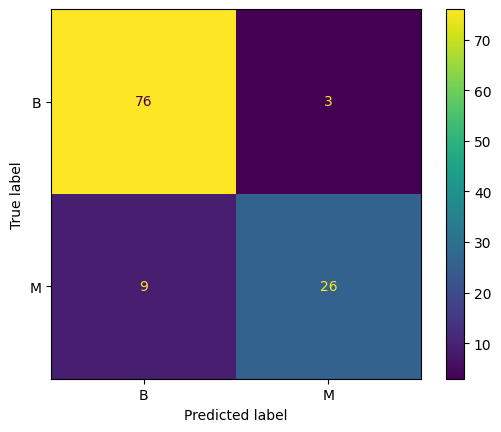

In [33]:
#import matplotlib
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from matplotlib import pyplot as plot

predict_y= network.predict(X_val)

print("Classifcation Report")
print(classification_report(y_val,predict_y))
print("Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_val, predict_y)
plot.show



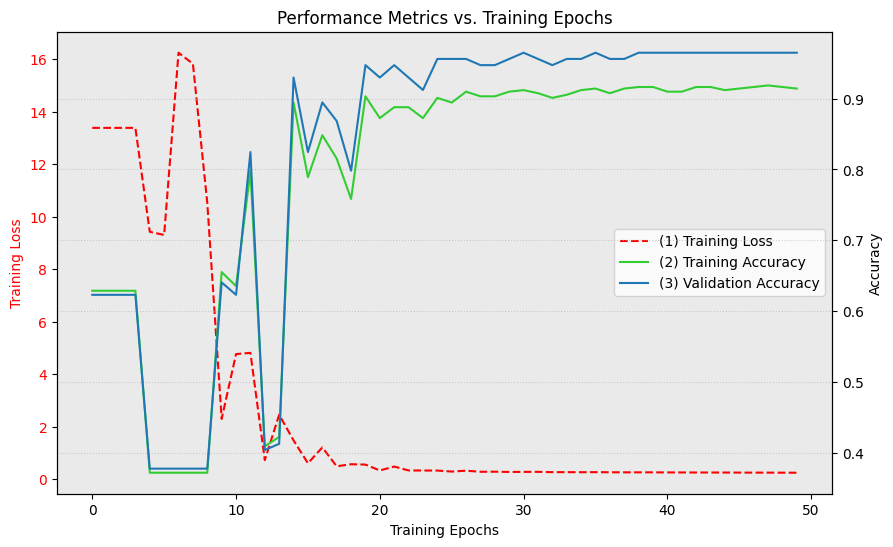

In [3]:
# 1. All our required imports
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plt

# 2. Fetch and split the data (Your exact naming scheme)
Diag_data = fetch_ucirepo(id=17)
X = Diag_data.data.features
y = Diag_data.data.targets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the blank tracking network
network_tracker = MLPClassifier(random_state=42)

# 4. Set up the empty lists for grading
epochs = 50
train_loss = []
train_acc = []
val_acc = []

# Find our B and M labels using your exact values.ravel() method
classes = np.unique(y_train.values.ravel()) 

# 5. Train the model one "Epoch" at a time in a loop
for i in range(epochs):
    # partial_fit trains for exactly 1 loop and stops
    network_tracker.partial_fit(X_train, y_train.values.ravel(), classes=classes)
    
    # Save the Loss (Error)
    train_loss.append(network_tracker.loss_curve_[-1])
    
    # Take the Practice Exam and save the score
    train_acc.append(network_tracker.score(X_train, y_train.values.ravel()))
    
    # Take the Unseen Final Exam and save the score
    val_acc.append(network_tracker.score(X_val, y_val.values.ravel()))

# --- 6. Plotting the Results ---

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor('#eaeaea') 

# Plot 1: Training Loss on the left Y-axis
ax1.set_xlabel('Training Epochs')
ax1.set_ylabel('Training Loss', color='red')
line1 = ax1.plot(train_loss, color='red', linestyle='--', label='(1) Training Loss')
ax1.tick_params(axis='y', labelcolor='red')

# Create a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()  

# Plot 2 & 3: Accuracies on the right Y-axis
ax2.set_ylabel('Accuracy', color='black')
line2 = ax2.plot(train_acc, color='limegreen', label='(2) Training Accuracy')
line3 = ax2.plot(val_acc, color='#1f77b4', label='(3) Validation Accuracy')
ax2.tick_params(axis='y', labelcolor='black')

# Combine the legends into one box
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Performance Metrics vs. Training Epochs')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()